# Assignment 1 — QANet

**COMP5329 / Deep Learning — University of Sydney, Semester 1 2026**

Run each section in order. Sections 0–1 are one-time setup steps; Sections 2–4 are the main training and evaluation pipeline.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your repo is stored elsewhere in Drive.
PROJECT_ROOT = "/content/drive/MyDrive/COMP5329_Assignment1-main"


Mounted at /content/drive


In [ ]:
# Install Python dependencies (run once per session)
!pip install -r {PROJECT_ROOT}/requirements.txt -q
!python -m spacy download en

---
## Section 0 — Environment Setup

Mount Google Drive and install dependencies.

In [3]:
import sys, os

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/COMP5329_Assignment1-main


---
## Section 1 — Download Data *(delete before submitting)*

Downloads the pre-built mini dataset (sampled SQuAD v1.1 train + full dev set,
with GloVe vectors filtered to the mini vocabulary) from GitHub Releases into `_data/`.

> **One-time step.** Once `_data/` exists on your Drive, delete this section before submission.

In [ ]:
from Tools.download import download_mini

download_mini(data_dir="_data")

Step 1 / 2  —  Mini dataset (SQuAD + GloVe)
  [skip] Mini dataset already present in _data/.

Step 2 / 2  —  spaCy language model
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Mini dataset download complete.


---
## Section 2 — Preprocess Data *(delete before submitting)*

Tokenises the SQuAD JSON files, builds word/char vocabularies from GloVe, and writes padded index tensors to `_data/`.

> **One-time step.** Once `_data/*.npz` exists on your Drive, delete this section before submission. Re-run only if you change `para_limit`, `ques_limit`, or other shape parameters.

In [ ]:
from Tools.preproc import preprocess

preprocess(
    train_file="_data/squad/train-mini.json",
    dev_file="_data/squad/dev-v1.1.json",
    glove_word_file="_data/glove/glove.mini.txt",
    target_dir="_data",
    para_limit=400,
    ques_limit=50,
)

Generating train examples…


100%|██████████| 150/150 [00:06<00:00, 24.65it/s]


  30293 questions in total
Generating dev examples…


100%|██████████| 48/48 [00:01<00:00, 28.08it/s]


  10570 questions in total
Generating word embedding…


...

100%|██████████| 30293/30293 [00:09<00:00, 3083.26it/s]


  Built 30169 / 30293 instances
Processing dev examples…


100%|██████████| 10570/10570 [00:03<00:00, 3177.22it/s]


  Built 10465 / 10570 instances
Saving word embedding…
Saving char embedding…
Saving train eval…
Saving dev eval…
Saving word dictionary…
Saving char dictionary…
Saving dev meta…

Preprocessing complete.
  Outputs → _data/


{'train_record_file': '_data/train.npz',
 'dev_record_file': '_data/dev.npz',
 'word_emb_file': '_data/word_emb.json',
 'char_emb_file': '_data/char_emb.json',
 'train_eval_file': '_data/train_eval.json',
 'dev_eval_file': '_data/dev_eval.json',
 'word2idx_file': '_data/word2idx.json',
 'char2idx_file': '_data/char2idx.json',
 'dev_meta_file': '_data/dev_meta.json'}

---
## Section 3 — Train

Trains QANet on SQuAD v1.1 and saves the best checkpoint to `_model/model.pt`.

In [ ]:
from TrainTools.train import train

results = train(
    # ── data paths (must match preprocess outputs) ──────────────────────
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    save_dir        = "_model",
    log_dir         = "_log",

    # ── training loop ────────────────────────────────────────────────────
    num_steps  = 60000,
    batch_size = 8,
    seed       = 42,

    # ── vanilla recipe: SGD, no scheduler, NLL loss ───────────────────────
    optimizer_name = "adam",
    scheduler_name = "step",
    loss_name      = "qa_nll",
)

print(f"Best F1: {results['best_f1']:.4f}  |  Best EM: {results['best_em']:.4f}")

Resuming from checkpoint: _model/model.pt
  Resumed at step 14800  best_f1=22.9373  best_em=18.2500


100%|██████████| 200/200 [01:06<00:00,  3.02it/s]


STEP    15000  loss 2.873439



100%|██████████| 150/150 [00:13<00:00, 11.13it/s]


VALID(train) loss 2.856785  F1 23.065892  EM 15.500000



...

STEP    22000  loss 2.775609



100%|██████████| 150/150 [00:14<00:00, 10.68it/s]


VALID(train) loss 2.638349  F1 27.470743  EM 21.333333



100%|██████████| 150/150 [00:13<00:00, 10.73it/s]


TEST        loss 3.237527  F1 24.389100  EM 19.416667

Learning rate: [0.0007033683215379002]
Early stopping triggered.
Training finished.  Best F1: 26.3782  Best EM: 21.0000
Best F1: 26.3782  |  Best EM: 21.0000


---
## Section 4 — Evaluate

Loads the saved checkpoint and runs inference on the full dev set.

In [ ]:
from EvaluateTools.evaluate import evaluate

metrics = evaluate(
    dev_npz       = "_data/dev.npz",
    word_emb_json = "_data/word_emb.json",
    char_emb_json = "_data/char_emb.json",
    dev_eval_json = "_data/dev_eval.json",
    save_dir      = "_model",
    log_dir       = "_log",
    ckpt_name     = "model.pt",
)

print(f"F1: {metrics['f1']:.4f}  |  EM: {metrics['exact_match']:.4f}  |  Loss: {metrics['loss']:.6f}")

100%|██████████| 1309/1309 [02:02<00:00, 10.72it/s]


TEST  loss 3.379290  F1 22.690816  EM 15.623507
F1: 22.6908  |  EM: 15.6235  |  Loss: 3.379290


# Section 5: stage 3-Experimental Investigation

| Section | Content |
|---------|-------------------|
| 1 | **Baseline** — Adam, lr=1e-3, dropout=0.1 |
| 2 | **Experiment 1** — Optimizer: SGD / Adam / SGD+Momentum |
| 3 | **Experiment 2** — Learning rate: 1e-2 / 1e-3 / 1e-4 |
| 4 | **Experiment 3** — norm_name: layer_norm/ norm_group-8/norm_group-4
| 5 | Results summary and plots |


In [4]:
import json, os
import matplotlib.pyplot as plt

!pip install ujson
from TrainTools.train import train

BASELINE_PATH = "_log/baseline.json"

# ── Shared base configuration ─────────────────────────────────────────────────
# Each experiment overrides ONLY the variable under investigation.
BASE = dict(
    # data paths
    train_npz       = "_data/train.npz",
    dev_npz         = "_data/dev.npz",
    word_emb_json   = "_data/word_emb.json",
    char_emb_json   = "_data/char_emb.json",
    train_eval_json = "_data/train_eval.json",
    dev_eval_json   = "_data/dev_eval.json",
    log_dir         = "_log",

    # training loop
    num_steps        = 3000,
    batch_size       = 8,
    checkpoint       = 500,
    val_num_batches  = 100,
    test_num_batches = 100,
    seed             = 42,
    grad_clip        = 5.0,
    early_stop       = 20,

    # fixed architecture — never changed across experiments
    d_model      = 96,
    num_heads    = 8,
    glove_dim    = 300,
    char_dim     = 64,
    para_limit   = 400,
    ques_limit   = 50,
    char_limit   = 16,
    norm_name    = "layer_norm",
    activation   = "relu",
    init_name    = "kaiming",

    # default training components
    loss_name      = "qa_nll",
    optimizer_name = "adam",
    scheduler_name = "none",
    learning_rate  = 1e-3,
    beta1          = 0.8,
    beta2          = 0.999,
    eps            = 1e-7,
    weight_decay   = 3e-7,
    momentum       = 0.9,
    dropout        = 0.1,
    dropout_char   = 0.05,
)

# Storage for current session's results
all_results = {}


def run(label, **overrides):
    """Train one configuration and store the result in all_results."""
    save_dir = os.path.join("_model", label)
    cfg = {**BASE, "save_dir": save_dir, **overrides}
    print(f"\n{'='*60}")
    print(f"  Running : {label}")
    print(f"  Changed : { {k: v for k, v in overrides.items()} }")
    print(f"{'='*60}")
    r = train(**cfg)
    all_results[label] = {
        "best_f1": r["best_f1"],
        "best_em": r["best_em"],
        "history": r["history"],
    }
    print(f"\n  >>> {label}:  Best F1={r['best_f1']:.4f}   EM={r['best_em']:.4f}")
    return r


def load_baseline():
    """
    Load the pre-trained baseline result from disk into all_results.
    Raises a clear error if Section 2 has not been run yet.
    """
    if not os.path.exists(BASELINE_PATH):
        raise FileNotFoundError(
            f"Baseline file not found: {BASELINE_PATH}\n"
            "Please run Section 2 first to train and save the baseline."
        )
    with open(BASELINE_PATH, "r") as f:
        data = json.load(f)
    all_results["baseline"] = data
    print(f"Baseline loaded from {BASELINE_PATH}")
    print(f"  Best F1={data['best_f1']:.4f}   EM={data['best_em']:.4f}")


os.makedirs("_log", exist_ok=True)
print("Shared configuration loaded. Ready to run experiments.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.8 MB/s eta 0:00:00
Shared configuration loaded. Ready to run experiments.


In [5]:
# Check whether the baseline has already been trained
if os.path.exists(BASELINE_PATH):
    print(f"Baseline already exists at {BASELINE_PATH}")
    print("Skip to the experiment section you want to run.")
    print("Or delete the file and re-run this cell to retrain.")
else:
    print("Baseline not found. Run the next cell to train it.")

Baseline already exists at _log/baseline.json
Skip to the experiment section you want to run.
Or delete the file and re-run this cell to retrain.


In [6]:
# Train the baseline (Adam, lr=1e-3, dropout=0.1)
run("baseline",
    optimizer_name = "adam",
    scheduler_name = "none",
    learning_rate  = 1e-3,
    dropout        = 0.1,
    dropout_char   = 0.05,
)

# Save baseline result to disk so it can be reused across sessions
with open(BASELINE_PATH, "w") as f:
    json.dump(all_results["baseline"], f, indent=2)
print(f"\nBaseline saved to {BASELINE_PATH}")


  Running : baseline
  Changed : {'optimizer_name': 'adam', 'scheduler_name': 'none', 'learning_rate': 0.001, 'dropout': 0.1, 'dropout_char': 0.05}
Resuming from checkpoint: _model/baseline/model.pt
  Resumed at step 3000  best_f1=20.8803  best_em=13.8750
Checkpoint already at step 3000 >= num_steps 3000. Nothing to do.

  >>> baseline:  Best F1=20.8803   EM=13.8750

Baseline saved to _log/baseline.json



| Run | optimizer | Expected behaviour |
|-----|-----------|--------------------|
| Baseline | `adam` | Loaded from file |
| Exp A | `sgd` | Slow convergence, loss plateaus early |
| Exp B | `sgd_momentum` | Faster than SGD, slower than Adam |

In [7]:
# Load baseline from file (no re-training)
load_baseline()
all_results["exp1_adam"] = all_results["baseline"]

Baseline loaded from _log/baseline.json
  Best F1=20.8803   EM=13.8750


In [8]:
# Experiment A — Vanilla SGD
run("exp1_sgd",
    optimizer_name = "sgd",
    scheduler_name = "none",
    learning_rate  = 1e-3,
)


  Running : exp1_sgd
  Changed : {'optimizer_name': 'sgd', 'scheduler_name': 'none', 'learning_rate': 0.001}
Resuming from checkpoint: _model/exp1_sgd/model.pt
  Resumed at step 3000  best_f1=6.9157  best_em=0.2500
Checkpoint already at step 3000 >= num_steps 3000. Nothing to do.

  >>> exp1_sgd:  Best F1=6.9157   EM=0.2500


{'best_f1': 6.91568331036173,
 'best_em': 0.25,
 'history': [{'step': 500,
   'train_loss': 25.908116933822633,
   'train_f1': 6.7134885766314065,
   'train_em': 0.0,
   'dev_loss': 7.8723815202713014,
   'dev_f1': 6.214104404664751,
   'dev_em': 0.125,
   'lr': 0.001},
  {'step': 1000,
   'train_loss': 9.37618262386322,
   'train_f1': 6.416970646584739,
   'train_em': 0.0,
   'dev_loss': 5.309894597530365,
   'dev_f1': 6.402140300698542,
   'dev_em': 0.125,
   'lr': 0.001},
  {'step': 1500,
   'train_loss': 6.43176203250885,
   'train_f1': 6.072402494349602,
   'train_em': 0.625,
   'dev_loss': 5.001996705532074,
   'dev_f1': 5.5003295290295515,
   'dev_em': 0.25,
   'lr': 0.001},
  {'step': 2000,
   'train_loss': 5.665240557670593,
   'train_f1': 7.009782785975234,
   'train_em': 0.125,
   'dev_loss': 4.833428797721862,
   'dev_f1': 6.91568331036173,
   'dev_em': 0.0,
   'lr': 0.001},
  {'step': 2500,
   'train_loss': 5.403351177215576,
   'train_f1': 7.7267479454833445,
   'train_em

In [9]:
# Experiment B — SGD with Momentum
run("exp1_sgdm",
    optimizer_name = "sgd_momentum",
    scheduler_name = "none",
    learning_rate  = 1e-3,
    momentum       = 0.9,
)


  Running : exp1_sgdm
  Changed : {'optimizer_name': 'sgd_momentum', 'scheduler_name': 'none', 'learning_rate': 0.001, 'momentum': 0.9}
Resuming from checkpoint: _model/exp1_sgdm/model.pt
  Resumed at step 3000  best_f1=6.6147  best_em=0.2500
Checkpoint already at step 3000 >= num_steps 3000. Nothing to do.

  >>> exp1_sgdm:  Best F1=6.6147   EM=0.2500


{'best_f1': 6.614727745588989,
 'best_em': 0.25,
 'history': [{'step': 500,
   'train_loss': 26.706750354766847,
   'train_f1': 6.60782317626288,
   'train_em': 0.0,
   'dev_loss': 8.104024653434754,
   'dev_f1': 5.888295902265261,
   'dev_em': 0.125,
   'lr': 0.001},
  {'step': 1000,
   'train_loss': 9.520726900100708,
   'train_f1': 6.774264215096824,
   'train_em': 0.125,
   'dev_loss': 5.357273564338684,
   'dev_f1': 6.099810561261597,
   'dev_em': 0.0,
   'lr': 0.001},
  {'step': 1500,
   'train_loss': 6.445539478302002,
   'train_f1': 5.5154538597192415,
   'train_em': 0.625,
   'dev_loss': 5.079085085391998,
   'dev_f1': 5.151075212788263,
   'dev_em': 0.125,
   'lr': 0.001},
  {'step': 2000,
   'train_loss': 5.675802640914917,
   'train_f1': 8.517293813538993,
   'train_em': 0.25,
   'dev_loss': 4.877134621143341,
   'dev_f1': 6.384587374840959,
   'dev_em': 0.125,
   'lr': 0.001},
  {'step': 2500,
   'train_loss': 5.398595475196839,
   'train_f1': 7.5435719329357145,
   'train


  Experiment 1: Optimizer Comparison
Config                  Best F1    Best EM
---------------------------------------------
Adam (baseline)         20.8803    13.8750
SGD                      6.9157     0.2500
SGD+Momentum             6.6147     0.2500


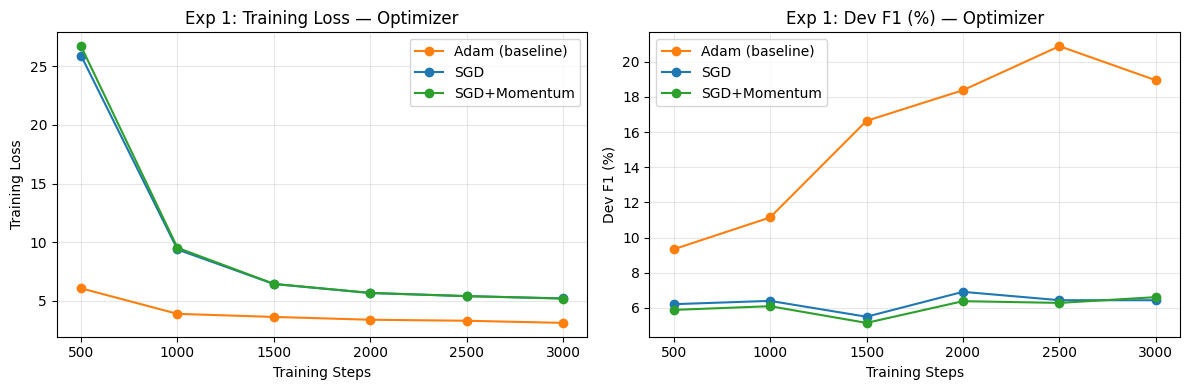

Plot saved to _log/exp1_optimizer.png


In [10]:
# Results table
print("\n" + "="*50)
print("  Experiment 1: Optimizer Comparison")
print("="*50)
print(f"{'Config':<20} {'Best F1':>10} {'Best EM':>10}")
print("-" * 45)
for key, label in [("exp1_adam", "Adam (baseline)"),
                   ("exp1_sgd",  "SGD"),
                   ("exp1_sgdm", "SGD+Momentum")]:
    r = all_results[key]
    print(f"{label:<20} {r['best_f1']:>10.4f} {r['best_em']:>10.4f}")

# Loss curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
variants = [("exp1_adam", "Adam (baseline)", "tab:orange"),
            ("exp1_sgd",  "SGD",             "tab:blue"),
            ("exp1_sgdm", "SGD+Momentum",    "tab:green")]
for metric, ax, ylabel in [("train_loss", axes[0], "Training Loss"),
                            ("dev_f1",    axes[1], "Dev F1 (%)")]:
    for key, label, color in variants:
        if key not in all_results:
            continue
        h = all_results[key]["history"]
        ax.plot([e["step"] for e in h], [e[metric] for e in h],
                marker="o", label=label, color=color)
    ax.set_title(f"Exp 1: {ylabel} — Optimizer")
    ax.set_xlabel("Training Steps")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("_log/exp1_optimizer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to _log/exp1_optimizer.png")

---
##  Learning Rate Sensitivity

| Run | learning_rate | Expected behaviour |
|-----|--------------|--------------------|
| Exp A | `1e-2` | Loss oscillates or diverges |
| Baseline | `1e-3` | Stable descent — loaded from file |
| Exp B | `1e-4` | Very slow descent, low F1 at step 3000 |

In [11]:
# Load baseline from file (no re-training)
load_baseline()
all_results["exp2_lr1e3"] = all_results["baseline"]

Baseline loaded from _log/baseline.json
  Best F1=20.8803   EM=13.8750


In [12]:
# Experiment A — large learning rate
run("exp2_lr1e2",
    optimizer_name = "adam",
    scheduler_name = "none",
    learning_rate  = 1e-2,
)


  Running : exp2_lr1e2
  Changed : {'optimizer_name': 'adam', 'scheduler_name': 'none', 'learning_rate': 0.01}
Resuming from checkpoint: _model/exp2_lr1e2/model.pt
  Resumed at step 3000  best_f1=17.3140  best_em=10.3750
Checkpoint already at step 3000 >= num_steps 3000. Nothing to do.

  >>> exp2_lr1e2:  Best F1=17.3140   EM=10.3750


{'best_f1': 17.3140120367118,
 'best_em': 10.375,
 'history': [{'step': 500,
   'train_loss': 6.206268774986267,
   'train_f1': 8.54418333937912,
   'train_em': 1.875,
   'dev_loss': 4.4685504794120785,
   'dev_f1': 9.817810658307868,
   'dev_em': 2.875,
   'lr': 0.01},
  {'step': 1000,
   'train_loss': 4.476174157142639,
   'train_f1': 11.388940246941624,
   'train_em': 5.0,
   'dev_loss': 4.122631521224975,
   'dev_f1': 10.00517710526093,
   'dev_em': 4.125,
   'lr': 0.01},
  {'step': 1500,
   'train_loss': 4.175090384960175,
   'train_f1': 9.923801027678863,
   'train_em': 3.25,
   'dev_loss': 4.240226702690125,
   'dev_f1': 10.58785781653879,
   'dev_em': 4.25,
   'lr': 0.01},
  {'step': 2000,
   'train_loss': 3.959088693141937,
   'train_f1': 13.165389693911859,
   'train_em': 6.625,
   'dev_loss': 3.5920802414417268,
   'dev_f1': 17.3140120367118,
   'dev_em': 10.375,
   'lr': 0.01},
  {'step': 2500,
   'train_loss': 3.9224369401931765,
   'train_f1': 14.883444926737859,
   'trai

In [13]:
# Experiment B — small learning rate
run("exp2_lr1e4",
    optimizer_name = "adam",
    scheduler_name = "none",
    learning_rate  = 1e-4,
)


  Running : exp2_lr1e4
  Changed : {'optimizer_name': 'adam', 'scheduler_name': 'none', 'learning_rate': 0.0001}
Resuming from checkpoint: _model/exp2_lr1e4/model.pt
  Resumed at step 3000  best_f1=10.4021  best_em=3.6250
Checkpoint already at step 3000 >= num_steps 3000. Nothing to do.

  >>> exp2_lr1e4:  Best F1=10.4021   EM=3.6250


{'best_f1': 10.402070386951753,
 'best_em': 3.625,
 'history': [{'step': 500,
   'train_loss': 14.356420404434203,
   'train_f1': 7.631350118124025,
   'train_em': 0.625,
   'dev_loss': 4.910014367103576,
   'dev_f1': 7.331252770182191,
   'dev_em': 0.625,
   'lr': 0.0001},
  {'step': 1000,
   'train_loss': 5.562467489719391,
   'train_f1': 9.21510101804719,
   'train_em': 2.0,
   'dev_loss': 4.314239287376404,
   'dev_f1': 8.259495450136908,
   'dev_em': 2.25,
   'lr': 0.0001},
  {'step': 1500,
   'train_loss': 4.661500101566315,
   'train_f1': 9.246944897519374,
   'train_em': 2.625,
   'dev_loss': 4.176336448192597,
   'dev_f1': 8.974095543475137,
   'dev_em': 2.75,
   'lr': 0.0001},
  {'step': 2000,
   'train_loss': 4.287366516590119,
   'train_f1': 9.234736784356734,
   'train_em': 2.625,
   'dev_loss': 4.07212367773056,
   'dev_f1': 9.633462276350922,
   'dev_em': 3.625,
   'lr': 0.0001},
  {'step': 2500,
   'train_loss': 4.157049152374268,
   'train_f1': 9.464923917036698,
   't


  Experiment 2: Learning Rate Sensitivity
Config                    Best F1    Best EM
-----------------------------------------------
Adam lr=1e-2              17.3140    10.3750
Adam lr=1e-3 (baseline)    20.8803    13.8750
Adam lr=1e-4              10.4021     3.6250


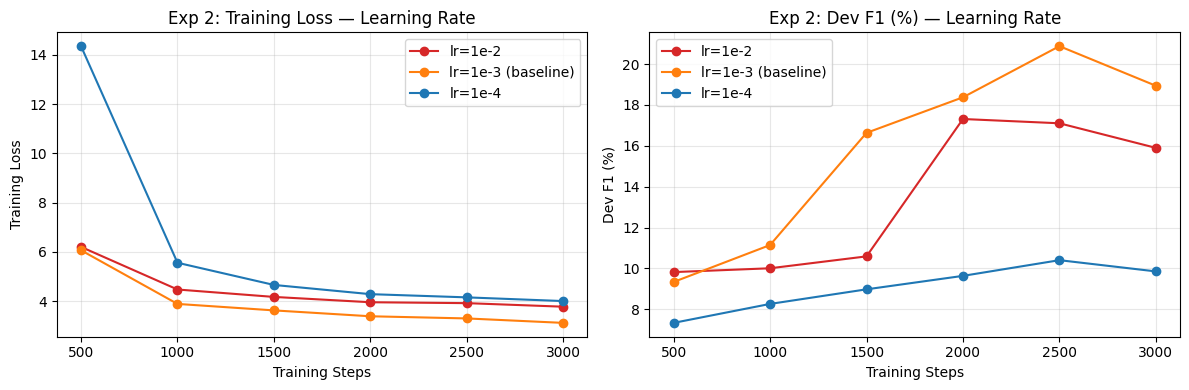

Plot saved to _log/exp2_learning_rate.png


In [14]:
# Results table
print("\n" + "="*50)
print("  Experiment 2: Learning Rate Sensitivity")
print("="*50)
print(f"{'Config':<22} {'Best F1':>10} {'Best EM':>10}")
print("-" * 47)
for key, label in [("exp2_lr1e2", "Adam lr=1e-2"),
                   ("exp2_lr1e3", "Adam lr=1e-3 (baseline)"),
                   ("exp2_lr1e4", "Adam lr=1e-4")]:
    r = all_results[key]
    print(f"{label:<22} {r['best_f1']:>10.4f} {r['best_em']:>10.4f}")

# Loss curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
variants = [("exp2_lr1e2", "lr=1e-2", "tab:red"),
            ("exp2_lr1e3", "lr=1e-3 (baseline)", "tab:orange"),
            ("exp2_lr1e4", "lr=1e-4", "tab:blue")]
for metric, ax, ylabel in [("train_loss", axes[0], "Training Loss"),
                            ("dev_f1",    axes[1], "Dev F1 (%)")]:
    for key, label, color in variants:
        if key not in all_results:
            continue
        h = all_results[key]["history"]
        ax.plot([e["step"] for e in h], [e[metric] for e in h],
                marker="o", label=label, color=color)
    ax.set_title(f"Exp 2: {ylabel} — Learning Rate")
    ax.set_xlabel("Training Steps")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("_log/exp2_learning_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to _log/exp2_learning_rate.png")

---
##  Normalization Strategy

| Run | norm_name | norm_groups | Expected behaviour |
|-----|-----------|-------------|--------------------|
| Baseline | `layer_norm` | — | Stable training — loaded from file |
| Exp A | `group_norm` | 8 | Higher loss variance, potentially lower dev F1 |
| Exp B | `group_norm` | 4 | Even larger instability due to fewer groups |


In [15]:
# Load baseline (LayerNorm) from file — no re-training needed
load_baseline()
all_results["exp3_layernorm"] = all_results["baseline"]


Baseline loaded from _log/baseline.json
  Best F1=20.8803   EM=13.8750


In [16]:
# Experiment A — GroupNorm with 8 groups
run("exp3_groupnorm8",
    optimizer_name = "adam",
    scheduler_name = "none",
    learning_rate  = 1e-3,
    dropout        = 0.1,
    dropout_char   = 0.05,
    norm_name      = "group_norm",
    norm_groups    = 8,
)



  Running : exp3_groupnorm8
  Changed : {'optimizer_name': 'adam', 'scheduler_name': 'none', 'learning_rate': 0.001, 'dropout': 0.1, 'dropout_char': 0.05, 'norm_name': 'group_norm', 'norm_groups': 8}
Resuming from checkpoint: _model/exp3_groupnorm8/model.pt
  Resumed at step 1000  best_f1=9.9155  best_em=5.2500


100%|██████████| 500/500 [02:49<00:00,  2.95it/s]


STEP     1500  loss 3.526520



100%|██████████| 100/100 [00:09<00:00, 10.20it/s]


VALID(train) loss 3.456301  F1 14.553007  EM 5.875000



...

100%|██████████| 100/100 [00:09<00:00, 10.19it/s]


VALID(train) loss 3.198536  F1 17.988743  EM 10.000000



100%|██████████| 100/100 [00:09<00:00, 10.18it/s]


TEST        loss 3.279639  F1 21.478424  EM 13.750000

Learning rate: [0.001]
Training finished.  Best F1: 21.7291  Best EM: 13.7500

  >>> exp3_groupnorm8:  Best F1=21.7291   EM=13.7500


{'best_f1': 21.729102148379283,
 'best_em': 13.75,
 'history': [{'step': 500,
   'train_loss': 5.73678046798706,
   'train_f1': 9.701070771355878,
   'train_em': 2.5,
   'dev_loss': 4.197591617107391,
   'dev_f1': 8.950831531182176,
   'dev_em': 1.75,
   'lr': 0.001},
  {'step': 1000,
   'train_loss': 3.8460631704330446,
   'train_f1': 12.935740315987973,
   'train_em': 6.5,
   'dev_loss': 4.087750792503357,
   'dev_f1': 9.91552113688129,
   'dev_em': 5.25,
   'lr': 0.001},
  {'step': 1500,
   'train_loss': 3.5265199172496797,
   'train_f1': 14.55300723485416,
   'train_em': 5.875,
   'dev_loss': 3.842259421348572,
   'dev_f1': 16.37508259664316,
   'dev_em': 9.0,
   'lr': 0.001},
  {'step': 2000,
   'train_loss': 3.2546039984226227,
   'train_f1': 17.787311636094046,
   'train_em': 10.0,
   'dev_loss': 3.8197463154792786,
   'dev_f1': 13.945768664946264,
   'dev_em': 8.5,
   'lr': 0.001},
  {'step': 2500,
   'train_loss': 3.3289187355041503,
   'train_f1': 20.131937517627176,
   'trai

In [17]:
# Experiment B — GroupNorm with 4 groups
run("exp3_groupnorm4",
    optimizer_name = "adam",
    scheduler_name = "none",
    learning_rate  = 1e-3,
    dropout        = 0.1,
    dropout_char   = 0.05,
    norm_name      = "group_norm",
    norm_groups    = 4,
)



  Running : exp3_groupnorm4
  Changed : {'optimizer_name': 'adam', 'scheduler_name': 'none', 'learning_rate': 0.001, 'dropout': 0.1, 'dropout_char': 0.05, 'norm_name': 'group_norm', 'norm_groups': 4}


100%|██████████| 500/500 [02:46<00:00,  3.00it/s]


STEP      500  loss 5.456656



100%|██████████| 100/100 [00:09<00:00, 10.61it/s]


VALID(train) loss 3.850685  F1 9.890167  EM 2.750000



...

100%|██████████| 100/100 [00:09<00:00, 10.60it/s]


VALID(train) loss 3.063342  F1 20.871352  EM 12.875000



100%|██████████| 100/100 [00:09<00:00, 10.61it/s]


TEST        loss 3.454862  F1 18.591723  EM 11.125000

Learning rate: [0.001]
Training finished.  Best F1: 20.6006  Best EM: 12.7500

  >>> exp3_groupnorm4:  Best F1=20.6006   EM=12.7500


{'best_f1': 20.600641056032305,
 'best_em': 12.75,
 'history': [{'step': 500,
   'train_loss': 5.456655813217163,
   'train_f1': 9.890167183364442,
   'train_em': 2.75,
   'dev_loss': 4.243098018169403,
   'dev_f1': 8.760117101431609,
   'dev_em': 1.875,
   'lr': 0.001},
  {'step': 1000,
   'train_loss': 3.8019723811149597,
   'train_f1': 13.902914410306849,
   'train_em': 6.75,
   'dev_loss': 3.932564971446991,
   'dev_f1': 11.254505944008175,
   'dev_em': 5.625,
   'lr': 0.001},
  {'step': 1500,
   'train_loss': 3.5515378103256228,
   'train_f1': 16.138481228457785,
   'train_em': 8.75,
   'dev_loss': 3.622370193004608,
   'dev_f1': 18.464783631787924,
   'dev_em': 11.125,
   'lr': 0.001},
  {'step': 2000,
   'train_loss': 3.3388020224571227,
   'train_f1': 17.046450597445265,
   'train_em': 9.5,
   'dev_loss': 3.392844430208206,
   'dev_f1': 18.972483057291512,
   'dev_em': 11.875,
   'lr': 0.001},
  {'step': 2500,
   'train_loss': 3.2924083449840547,
   'train_f1': 21.5519147975735


  Experiment 3: Normalization Strategy
Config                            Best F1    Best EM   Loss Var
--------------------------------------------------------------
LayerNorm (baseline)              20.8803    13.8750   1.000813
GroupNorm  G=8                    21.7291    13.7500   0.791427
GroupNorm  G=4                    20.6006    12.7500   0.622058


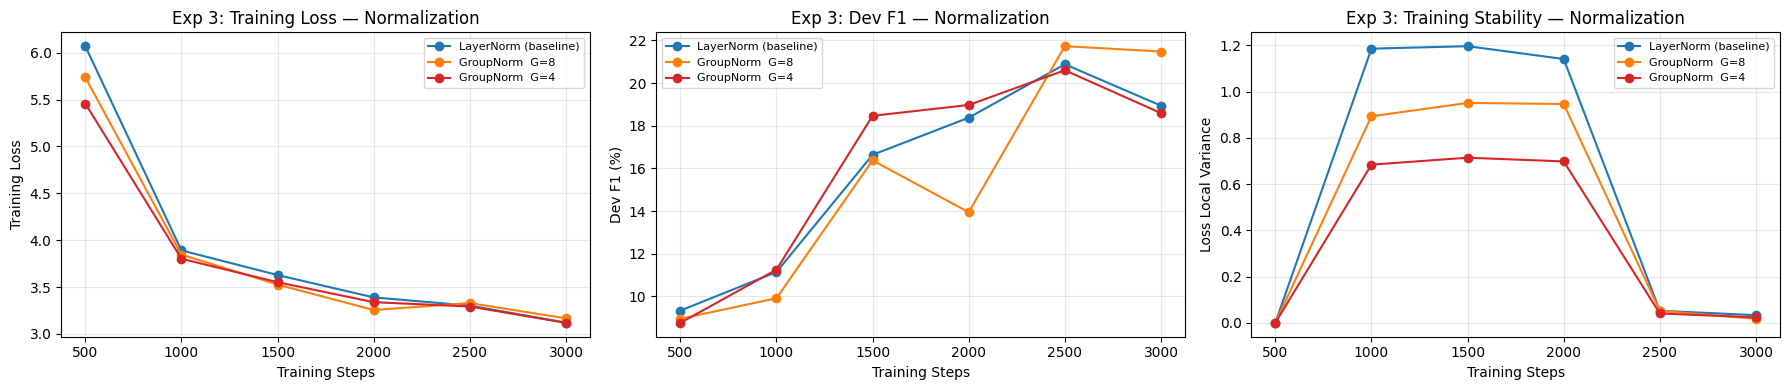

Plot saved to _log/exp3_normalization.png

Hypothesis verdict:
  LayerNorm F1=20.8803 | GroupNorm G=8 F1=21.7291 | GroupNorm G=4 F1=20.6006
  ✗ Hypothesis not fully supported — see loss variance for stability analysis


In [18]:
# Results table
import numpy as np

print("\n" + "="*58)
print("  Experiment 3: Normalization Strategy")
print("="*58)
print(f"{'Config':<30} {'Best F1':>10} {'Best EM':>10} {'Loss Var':>10}")
print("-" * 62)
for key, label in [("exp3_layernorm",   "LayerNorm (baseline)"),
                   ("exp3_groupnorm8",  "GroupNorm  G=8"),
                   ("exp3_groupnorm4",  "GroupNorm  G=4")]:
    if key not in all_results:
        continue
    r      = all_results[key]
    losses = [h["train_loss"] for h in r["history"]]
    lvar   = float(np.var(losses)) if losses else float("nan")
    print(f"{label:<30} {r['best_f1']:>10.4f} {r['best_em']:>10.4f} {lvar:>10.6f}")

# ── Rolling variance helper ───────────────────────────────────────────────
def rolling_var(vals, w=3):
    return [float(np.var(vals[max(0, i-w):i+1])) for i in range(len(vals))]

# ── Three-panel plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
variants = [
    ("exp3_layernorm",  "LayerNorm (baseline)", "tab:blue"),
    ("exp3_groupnorm8", "GroupNorm  G=8",        "tab:orange"),
    ("exp3_groupnorm4", "GroupNorm  G=4",        "tab:red"),
]

for metric, ax, ylabel, title in [
    ("train_loss", axes[0], "Training Loss",         "Exp 3: Training Loss — Normalization"),
    ("dev_f1",     axes[1], "Dev F1 (%)",            "Exp 3: Dev F1 — Normalization"),
    ("train_loss", axes[2], "Loss Local Variance",   "Exp 3: Training Stability — Normalization"),
]:
    for key, label, color in variants:
        if key not in all_results:
            continue
        h      = all_results[key]["history"]
        steps  = [e["step"] for e in h]
        values = [e[metric] for e in h]
        if ax == axes[2]:   # stability panel uses rolling variance
            values = rolling_var(values)
        ax.plot(steps, values, marker="o", label=label, color=color)
    ax.set_title(title)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("_log/exp3_normalization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to _log/exp3_normalization.png")

# ── Hypothesis verdict ────────────────────────────────────────────────────
ln_f1 = all_results.get("exp3_layernorm",  {}).get("best_f1", 0)
g8_f1 = all_results.get("exp3_groupnorm8", {}).get("best_f1", 0)
g4_f1 = all_results.get("exp3_groupnorm4", {}).get("best_f1", 0)
print("\nHypothesis verdict:")
print(f"  LayerNorm F1={ln_f1:.4f} | GroupNorm G=8 F1={g8_f1:.4f} | GroupNorm G=4 F1={g4_f1:.4f}")
print("  " + ("✓ LayerNorm outperforms GroupNorm — hypothesis supported"
               if ln_f1 > g8_f1 and ln_f1 > g4_f1
               else "✗ Hypothesis not fully supported — see loss variance for stability analysis"))


# Section 6-result

In [19]:
# Save all results to JSON
summary = {k: {"best_f1": v["best_f1"], "best_em": v["best_em"]}
           for k, v in all_results.items()}
with open("_log/stage3_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

with open("_log/stage3_history.json", "w") as f:
    json.dump({k: v["history"] for k, v in all_results.items()}, f, indent=2)

print("Saved: _log/stage3_summary.json")
print("Saved: _log/stage3_history.json")


Saved: _log/stage3_summary.json
Saved: _log/stage3_history.json


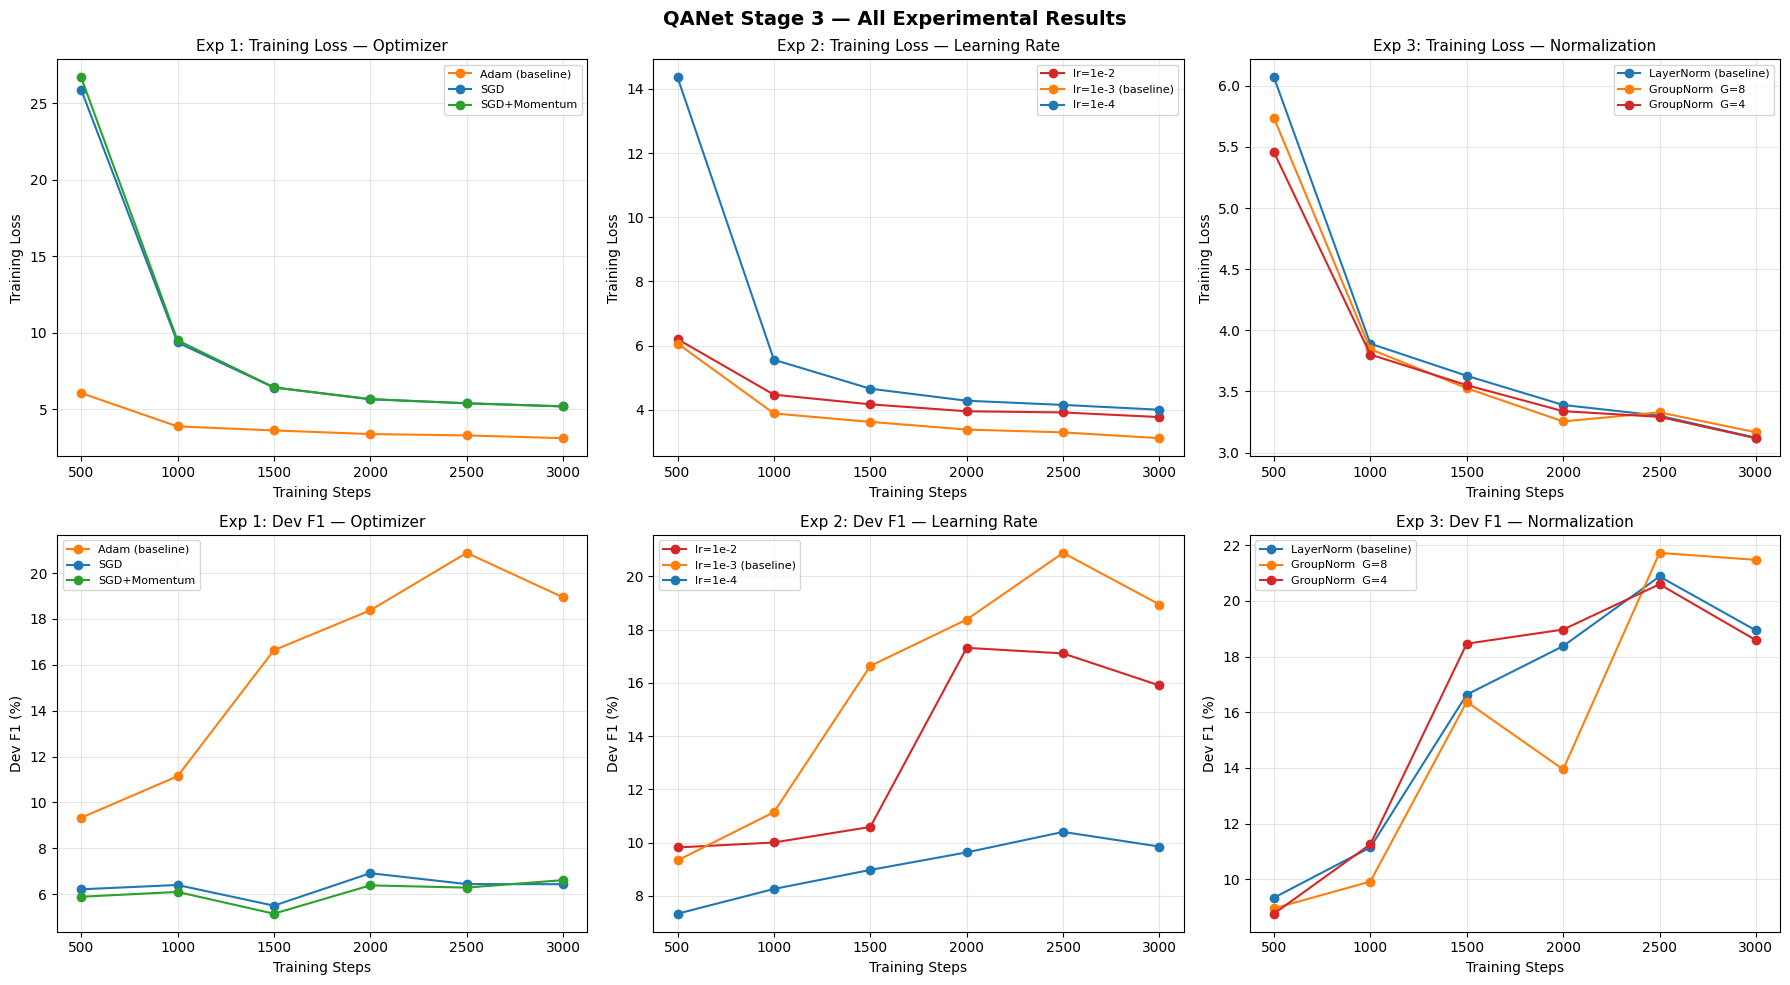

Combined plot saved to _log/stage3_results.png


In [20]:
# Combined 2x3 figure: training loss + dev F1 for all three experiments
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_specs = [
    ("Exp 1: Training Loss — Optimizer",
     [("exp1_adam", "Adam (baseline)", "tab:orange"),
      ("exp1_sgd",  "SGD",             "tab:blue"),
      ("exp1_sgdm", "SGD+Momentum",    "tab:green")],
     "train_loss"),
    ("Exp 2: Training Loss — Learning Rate",
     [("exp2_lr1e2", "lr=1e-2",             "tab:red"),
      ("exp2_lr1e3", "lr=1e-3 (baseline)",  "tab:orange"),
      ("exp2_lr1e4", "lr=1e-4",             "tab:blue")],
     "train_loss"),
    ("Exp 3: Training Loss — Normalization",
     [("exp3_layernorm",  "LayerNorm (baseline)", "tab:blue"),
      ("exp3_groupnorm8", "GroupNorm  G=8",        "tab:orange"),
      ("exp3_groupnorm4", "GroupNorm  G=4",        "tab:red")],
     "train_loss"),
    ("Exp 1: Dev F1 — Optimizer",
     [("exp1_adam", "Adam (baseline)", "tab:orange"),
      ("exp1_sgd",  "SGD",             "tab:blue"),
      ("exp1_sgdm", "SGD+Momentum",    "tab:green")],
     "dev_f1"),
    ("Exp 2: Dev F1 — Learning Rate",
     [("exp2_lr1e2", "lr=1e-2",             "tab:red"),
      ("exp2_lr1e3", "lr=1e-3 (baseline)",  "tab:orange"),
      ("exp2_lr1e4", "lr=1e-4",             "tab:blue")],
     "dev_f1"),
    ("Exp 3: Dev F1 — Normalization",
     [("exp3_layernorm",  "LayerNorm (baseline)", "tab:blue"),
      ("exp3_groupnorm8", "GroupNorm  G=8",        "tab:orange"),
      ("exp3_groupnorm4", "GroupNorm  G=4",        "tab:red")],
     "dev_f1"),
]

for ax, (title, variants, metric) in zip(axes.flat, plot_specs):
    for key, label, color in variants:
        if key not in all_results:
            continue
        h = all_results[key]["history"]
        ax.plot([e["step"] for e in h], [e[metric] for e in h],
                marker="o", label=label, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Training Steps")
    ax.set_ylabel("Training Loss" if metric == "train_loss" else "Dev F1 (%)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("QANet Stage 3 — All Experimental Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("_log/stage3_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Combined plot saved to _log/stage3_results.png")


In [21]:
# Final summary table
print("\n" + "="*55)
print("  STAGE 3 COMPLETE SUMMARY")
print("="*55)
print(f"{'Run':<32} {'Best F1':>10} {'Best EM':>10}")
print("-" * 55)
display_order = [
    ("exp1_adam",        "Exp1  Adam (baseline)"),
    ("exp1_sgd",         "Exp1  SGD"),
    ("exp1_sgdm",        "Exp1  SGD+Momentum"),
    ("exp2_lr1e2",       "Exp2  lr=1e-2"),
    ("exp2_lr1e3",       "Exp2  lr=1e-3 (baseline)"),
    ("exp2_lr1e4",       "Exp2  lr=1e-4"),
    ("exp3_layernorm",   "Exp3  LayerNorm (baseline)"),
    ("exp3_groupnorm8",  "Exp3  GroupNorm G=8"),
    ("exp3_groupnorm4",  "Exp3  GroupNorm G=4"),
]
for key, label in display_order:
    if key in all_results:
        r = all_results[key]
        print(f"{label:<32} {r['best_f1']:>10.4f} {r['best_em']:>10.4f}")
    else:
        print(f"{label:<32} {'(not run yet)':>22}")



  STAGE 3 COMPLETE SUMMARY
Run                                 Best F1    Best EM
-------------------------------------------------------
Exp1  Adam (baseline)               20.8803    13.8750
Exp1  SGD                            6.9157     0.2500
Exp1  SGD+Momentum                   6.6147     0.2500
Exp2  lr=1e-2                       17.3140    10.3750
Exp2  lr=1e-3 (baseline)            20.8803    13.8750
Exp2  lr=1e-4                       10.4021     3.6250
Exp3  LayerNorm (baseline)          20.8803    13.8750
Exp3  GroupNorm G=8                 21.7291    13.7500
Exp3  GroupNorm G=4                 20.6006    12.7500
